# 실전 14-2: 시각 데이터 분석 및 UI 클론(Clone)

## 1. 프론트엔드 개발 자동화 (UI Clone)
- 디자이너가 Figma나 이미지로 시안을 넘겨주면, 개발자가 일일이 HTML/CSS를 타이핑하던 시대가 저물고 있습니다.
- 캡처 화면을 주고 **"이 이미지와 똑같이 작동하는 프론트엔드 코드를 짜줘"** 라고 명령하는 실무 패턴을 알아봅니다.

=== [디자이너가 넘겨준 UI 시안] ===


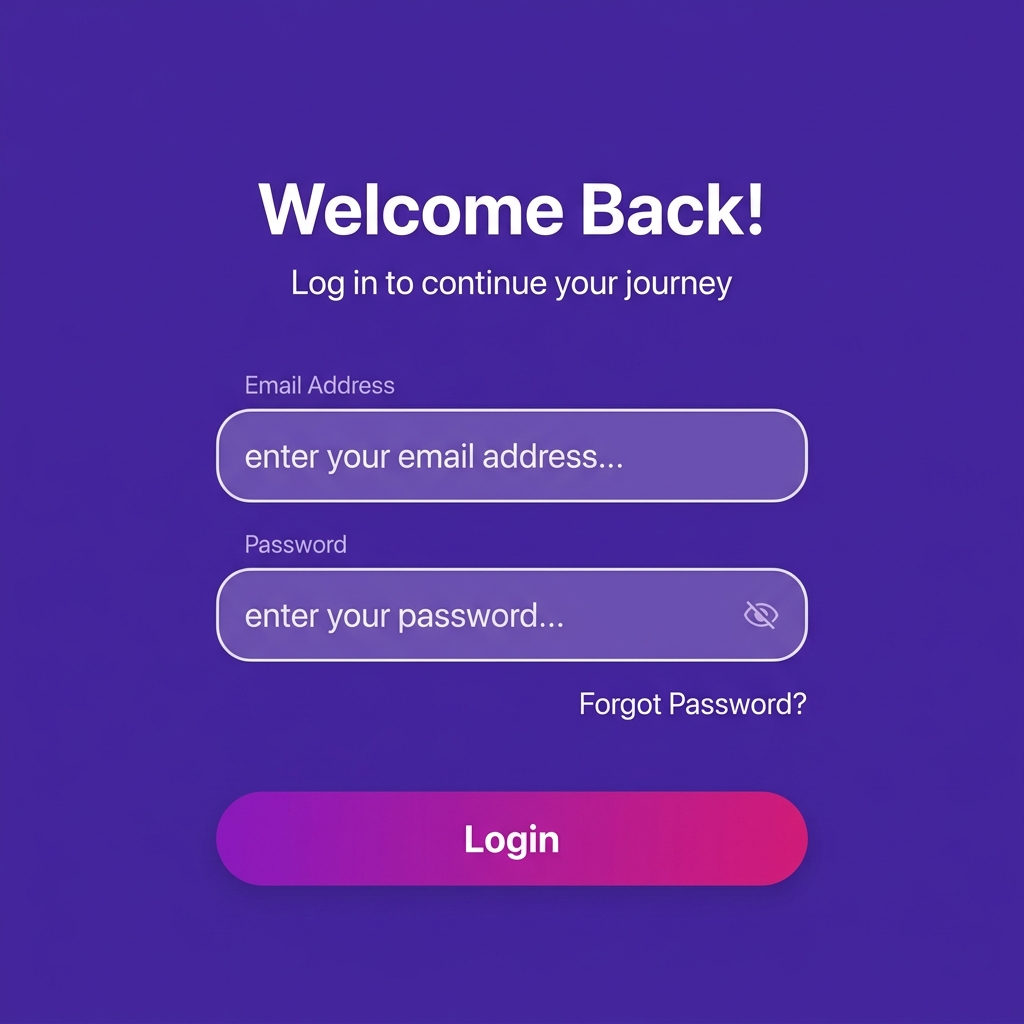

In [1]:
import base64
from IPython.display import Image, display
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

ui_image_path = "images/login_ui.png"

print("=== [디자이너가 넘겨준 UI 시안] ===")
display(Image(filename=ui_image_path, width=300))

## 2. LLM에게 HTML/CSS 코드 굽기 요청
복사-붙여넣기 가능한 완벽한 코드를 얻어냅니다.

In [2]:
def encode_image(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode('utf-8')

base64_ui = encode_image(ui_image_path)

message = HumanMessage(
    content=[
        {"type": "text", "text": "이 이미지는 모바일 앱의 로그인 화면 시안이야. 이 화면과 100% 동일하게 보이도록 HTML과 CSS(Tailwind CSS 사용 가능) 코드를 작성해 줘. 마크다운 형식으로 코드만 출력해."},
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/png;base64,{base64_ui}"}
        }
    ]
)

print("=== [AI가 작성한 UI 코드] ===")
code_response = llm.invoke([message])
print(code_response.content)

=== [AI가 작성한 UI 코드] ===
```html
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <link href="https://cdn.jsdelivr.net/npm/tailwindcss@2.2.19/dist/tailwind.min.css" rel="stylesheet">
    <title>Login Screen</title>
</head>
<body class="bg-purple-600 flex items-center justify-center h-screen">
    <div class="bg-white rounded-lg shadow-lg p-8 w-80">
        <h1 class="text-2xl font-bold text-center text-purple-600">Welcome Back!</h1>
        <p class="text-center text-gray-500 mb-6">Log in to continue your journey</p>
        <label class="block text-gray-700 mb-1">Email Address</label>
        <input type="email" placeholder="enter your email address..." class="border border-gray-300 rounded-lg p-2 w-full mb-4">
        <label class="block text-gray-700 mb-1">Password</label>
        <input type="password" placeholder="enter your password..." class="border border-gray-300 rounded-lg p-2 w-fu

## 3. 시각 데이터를 구조화된 JSON으로 뽑아내기
- 실무에서는 이력서 이미지, 차트, 복잡한 양식의 신청서 스캔본 등을 DB에 넣기 편한 JSON 형식으로 바꿔야 할 때가 많습니다.
- 3장의 `Structured Output (Pydantic)` 기술과 결합하면 멀티모달의 힘이 극대화됩니다.

In [3]:
from pydantic import BaseModel, Field

# 1. 뽑아내고 싶은 데이터 구조(Schema) 정의
class UIAnalysis(BaseModel):
    background_color: str = Field(description="전체 배경색 (예: 보라색, 파란색 등)")
    title_text: str = Field(description="화면 상단의 큰 제목 텍스트")
    input_fields: list[str] = Field(description="사용자가 입력해야 하는 필드들의 종류 리스트")
    button_text: str = Field(description="하단 로그인 버튼에 적힌 텍스트")

# 2. 구조화된 출력(Structured Output) 활성화
structured_llm = llm.with_structured_output(UIAnalysis)

# 3. 멀티모달 요청
json_message = HumanMessage(
    content=[
        {"type": "text", "text": "이 UI 화면의 핵심 디자인 요소들을 추출해줘."},
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/png;base64,{base64_ui}"}
        }
    ]
)

print("=== [시각 데이터 -> JSON 자동 변환] ===")
analysis_result = structured_llm.invoke([json_message])

print(f"배경색: {analysis_result.background_color}")
print(f"헤더: {analysis_result.title_text}")
print(f"입력창 종류: {analysis_result.input_fields}")
print(f"버튼 글씨: {analysis_result.button_text}")

=== [시각 데이터 -> JSON 자동 변환] ===
배경색: #6A0DAD
헤더: Welcome Back!
입력창 종류: ['Email Address', 'Password']
버튼 글씨: Login


## 4. 결론
- OCR API를 따로 쓰지 않고도, 이미지 속 글자(Text)와 레이아웃(Layout)을 LLM이 직관적으로 이해합니다.
- 이를 Pydantic과 엮으면 **"어떤 양식이든 캡처해서 던지면 정형화된 DB 데이터로 변환해 주는 파이프라인"**을 단 10줄의 코드로 구축할 수 있습니다.